# Passive Coating Outdoor Temperature â€” EDA
**Dataset:** 24-hour outdoor measurement, 2026-04-27 (1-min intervals, 1440 rows)

**Goal:** Understand temperature and sub-ambient Î”T behaviour of 20 coating samples vs a bare reference.

**Sample IDs:** REF = bare substrate reference Â· S01â€“S19 = coating formulations (anonymized)

`dT_*` columns = sample Â°C âˆ’ REF Â°C  (negative = cooler than reference = good performance)

## Background & Experimental Context

**What is radiative cooling?**
Passive radiative cooling (RC) coatings lower surface temperature without electricity.
They work by two mechanisms: (1) reflecting sunlight (high solar reflectance, ideally >0.85),
and (2) emitting heat as infrared radiation through the atmospheric window (8-13 um),
where the sky is semi-transparent and acts as a heat sink at ~3 K.

**Why Bangkok is a hard test case.**
Most published RC data comes from dry climates (Arizona, Gobi, Middle East) where the
8-13 um atmospheric window is wide open. Bangkok's year-round humidity (RH 75-85%)
means water vapour partially fills the window, reducing the effective sky emittance
and making sub-ambient cooling harder to achieve. A coating that delivers -5 degC in Arizona
may deliver only -1 to -2 degC in Bangkok. This dataset tests whether measurable cooling
is achievable at all under these conditions.

**This dataset.**
- Date: 2026-04-27 (hot season, high solar input)
- Duration: 24 hours, 1-minute intervals (1440 rows)
- Setup: 19 coating samples (S01-S19) on identical substrates placed outdoors alongside
  a bare reference (REF). All samples face the sky.
- Measurement: surface thermocouple at each sample.
- Target variable: DeltaT = sample temperature - REF temperature (degC).
  **Negative DeltaT = cooler than bare reference = good RC performance.**
- REF surface temperature at solar noon (11:30-12:30): ~30.7 degC.

## 1. Load & Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

df = pd.read_csv('../data/raw/outdoor_temp_2026-04-27.csv', parse_dates=['Time'])
df = df.set_index('Time').sort_index()
raw_cols = [c for c in df.columns if not c.startswith('dT_')]
sub_cols = [c for c in df.columns if c.startswith('dT_')]
print(f'Shape: {df.shape}')
print(f'Date range: {df.index[0]}  to  {df.index[-1]}')
print(f'Raw temp cols ({len(raw_cols)}): {raw_cols}')
print(f'DeltaT cols   ({len(sub_cols)}): {sub_cols}')
df.head(3)

Shape: (1440, 39)
Date range: 2026-04-27 00:00:51  to  2026-04-27 23:59:51
Raw temp cols (20): ['REF', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19']
DeltaT cols   (19): ['dT_S01', 'dT_S02', 'dT_S03', 'dT_S04', 'dT_S05', 'dT_S06', 'dT_S07', 'dT_S08', 'dT_S09', 'dT_S10', 'dT_S11', 'dT_S12', 'dT_S13', 'dT_S14', 'dT_S15', 'dT_S16', 'dT_S17', 'dT_S18', 'dT_S19']


,REF,S01,S02,S03,S04,S05,S06,S07,S08,S09,...,dT_S10,dT_S11,dT_S12,dT_S13,dT_S14,dT_S15,dT_S16,dT_S17,dT_S18,dT_S19
Time,,,,,,,,,,,,,,,,,,,,,
2026-04-27 00:00:51,33.134770,33.134543,32.930476,33.033578,33.106536,33.083149,33.141793,33.115690,33.243751,33.290198,...,-0.023255,-0.006935,-0.025268,-0.050451,0.060769,0.134285,-0.077740,0.045832,-0.070707,-0.048577
2026-04-27 00:01:51,33.070647,33.101056,32.873405,32.964211,33.071646,33.014549,32.934422,32.862189,32.926128,33.223346,...,-0.097815,-0.061193,-0.006487,-0.108240,-0.006593,0.060326,-0.036986,-0.001501,-0.009986,-0.053517
2026-04-27 00:02:51,33.105941,33.076802,32.999529,33.079158,33.017061,33.094738,33.084542,32.992360,33.062576,33.139664,...,0.032249,-0.050106,-0.004559,-0.116923,0.084784,0.099690,0.002378,0.012192,-0.135114,0.003358


## 2. Basic Statistics

In [2]:
print('--- Raw temperature summary (degC) ---')
display(df[raw_cols].describe().round(2))
print('--- DeltaT summary (degC, relative to REF) ---')
df[sub_cols].describe().round(3)

--- Raw temperature summary (degC) ---


,REF,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12,S13,S14,S15,S16,S17,S18,S19
count,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00,1440.00
mean,31.30,31.17,31.08,30.97,31.19,31.10,31.00,30.89,31.40,31.87,31.23,31.26,31.18,31.05,31.44,31.99,31.11,31.37,31.02,31.14
std,3.35,3.38,3.39,3.42,3.37,3.39,3.41,3.43,3.34,3.30,3.36,3.36,3.37,3.40,3.33,3.30,3.38,3.35,3.40,3.38
min,25.72,25.60,25.51,25.50,25.66,25.45,25.55,25.40,25.63,25.84,25.68,25.63,25.61,25.54,25.72,25.88,25.60,25.65,25.57,25.58
25%,28.10,27.90,27.81,27.67,27.93,27.87,27.69,27.58,28.22,28.82,28.02,28.02,27.96,27.76,28.24,28.92,27.86,28.19,27.72,27.89
50%,31.83,31.63,31.51,31.31,31.67,31.51,31.37,31.19,32.00,32.81,31.72,31.77,31.66,31.42,32.05,33.03,31.57,31.94,31.40,31.60
75%,34.49,34.40,34.36,34.27,34.41,34.34,34.31,34.24,34.52,34.89,34.47,34.45,34.41,34.32,34.54,35.01,34.36,34.53,34.30,34.37
max,35.83,35.83,35.78,35.83,35.89,35.81,35.87,35.81,35.96,36.03,35.85,35.88,35.84,35.82,35.98,36.03,35.85,35.94,35.76,35.83


--- DeltaT summary (degC, relative to REF) ---


,dT_S01,dT_S02,dT_S03,dT_S04,dT_S05,dT_S06,dT_S07,dT_S08,dT_S09,dT_S10,dT_S11,dT_S12,dT_S13,dT_S14,dT_S15,dT_S16,dT_S17,dT_S18,dT_S19
count,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000
mean,-0.135,-0.223,-0.335,-0.109,-0.199,-0.298,-0.408,0.102,0.566,-0.072,-0.044,-0.122,-0.251,0.136,0.690,-0.186,0.065,-0.278,-0.157
std,0.140,0.204,0.307,0.119,0.191,0.277,0.366,0.111,0.618,0.090,0.077,0.124,0.229,0.140,0.753,0.174,0.082,0.251,0.150
min,-0.526,-0.721,-1.044,-0.457,-0.696,-0.949,-1.266,-0.152,-0.079,-0.414,-0.292,-0.468,-0.831,-0.153,-0.050,-0.620,-0.190,-0.914,-0.562
25%,-0.242,-0.394,-0.602,-0.194,-0.357,-0.533,-0.709,0.021,0.088,-0.135,-0.093,-0.218,-0.449,0.029,0.108,-0.332,0.009,-0.496,-0.277
50%,-0.093,-0.137,-0.174,-0.084,-0.123,-0.158,-0.206,0.079,0.180,-0.063,-0.041,-0.093,-0.148,0.094,0.202,-0.123,0.057,-0.161,-0.109
75%,-0.029,-0.062,-0.097,-0.020,-0.051,-0.082,-0.128,0.183,1.118,-0.006,0.008,-0.029,-0.074,0.245,1.360,-0.051,0.122,-0.083,-0.044
max,0.152,0.166,0.069,0.182,0.127,0.099,0.073,0.457,1.897,0.152,0.259,0.146,0.157,0.490,2.271,0.128,0.307,0.071,0.171


## 3. Data Quality Check

In [3]:
missing = df.isnull().sum()
print('Missing values:', 'None' if missing.sum()==0 else missing[missing>0].to_dict())
diffs = df.index.to_series().diff().dropna()
gaps = diffs[diffs != pd.Timedelta('1min')]
print(f'Time-interval gaps (expect 1 min): {len(gaps)} found')
if not gaps.empty: print(gaps)

Missing values: None
Time-interval gaps (expect 1 min): 0 found


## 4. 24-Hour Temperature Profiles

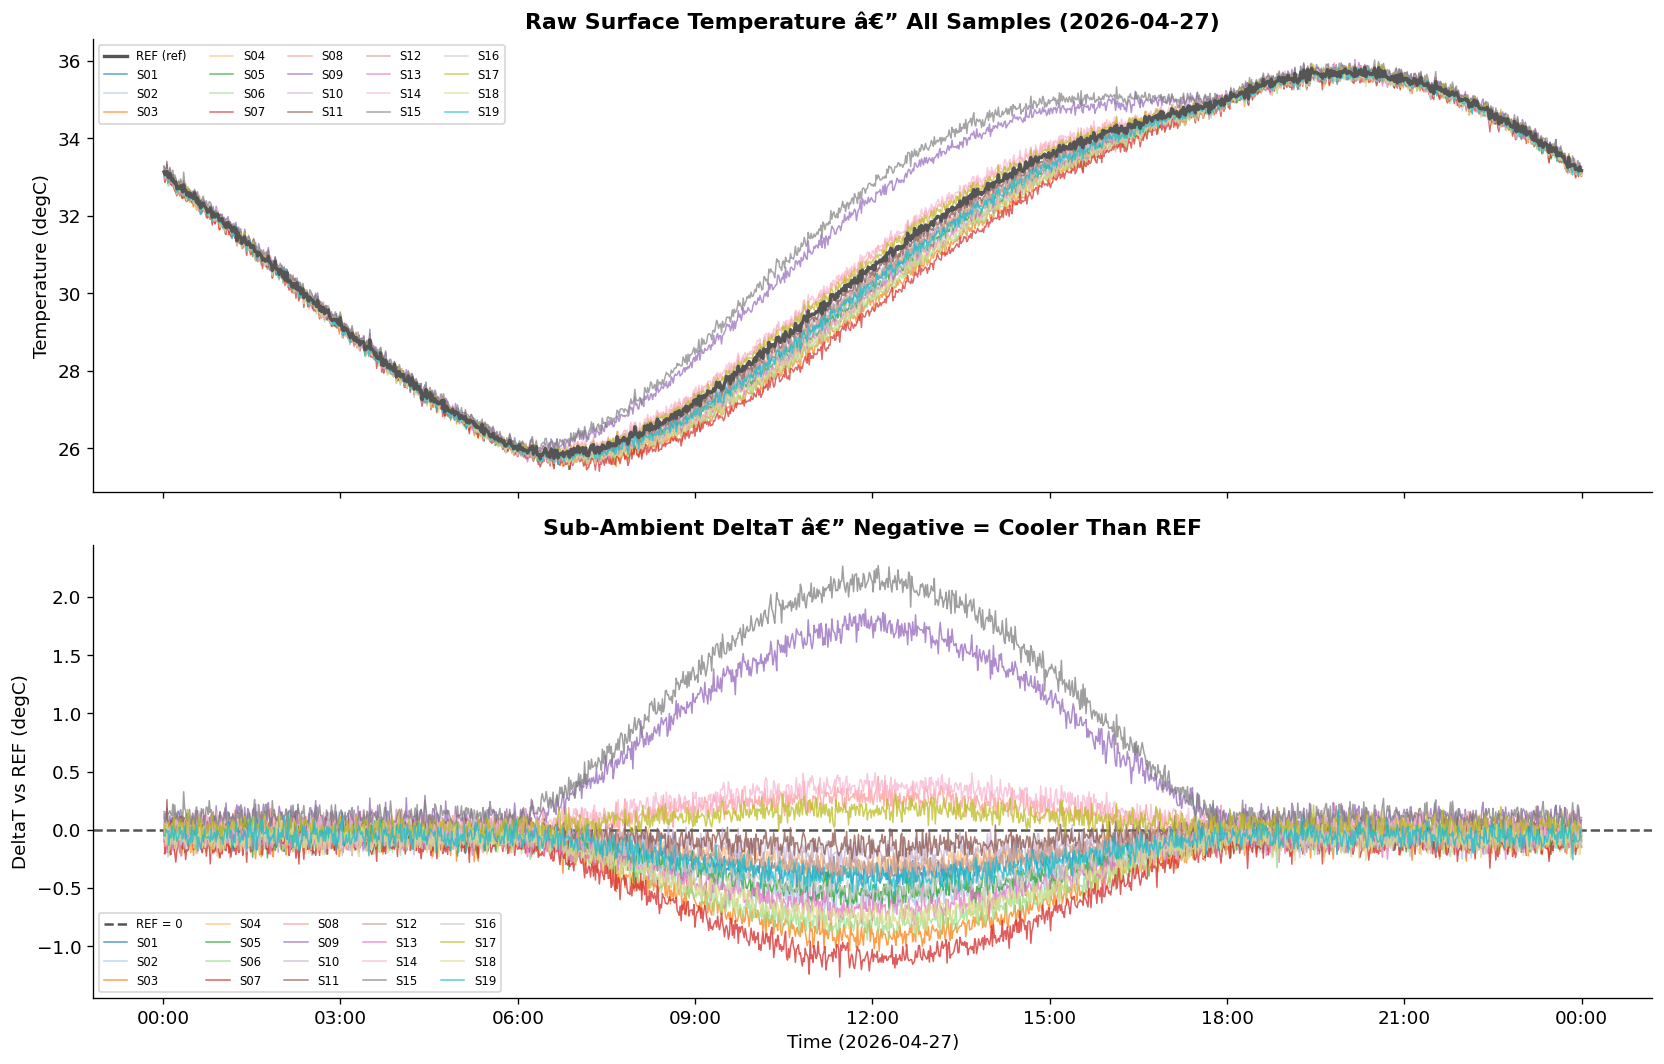

Saved: 01_temperature_profiles.png


In [4]:
fig, axes = plt.subplots(2,1,figsize=(14,9),sharex=True)
palette = plt.cm.tab20.colors

ax1 = axes[0]
ax1.plot(df.index, df['REF'], color='#555', lw=2, label='REF (ref)', zorder=5)
for i,col in enumerate(raw_cols[1:]):
    ax1.plot(df.index, df[col], lw=0.9, alpha=0.7, color=palette[i], label=col)
ax1.set_ylabel('Temperature (degC)')
ax1.set_title('Raw Surface Temperature â€” All Samples (2026-04-27)', fontweight='bold')
ax1.legend(fontsize=7, ncol=5, loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax2 = axes[1]
ax2.axhline(0, color='#555', lw=1.5, ls='--', label='REF = 0')
for i,col in enumerate(sub_cols):
    ax2.plot(df.index, df[col], lw=0.9, alpha=0.75, color=palette[i], label=col.replace('dT_',''))
ax2.set_ylabel('DeltaT vs REF (degC)')
ax2.set_xlabel('Time (2026-04-27)')
ax2.set_title('Sub-Ambient DeltaT â€” Negative = Cooler Than REF', fontweight='bold')
ax2.legend(fontsize=7, ncol=5, loc='lower left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.savefig(FIGURES/'01_temperature_profiles.png', bbox_inches='tight')
plt.show()
print('Saved: 01_temperature_profiles.png')

## 5. Peak Cooling Performance (Daytime 06:00â€“18:00)

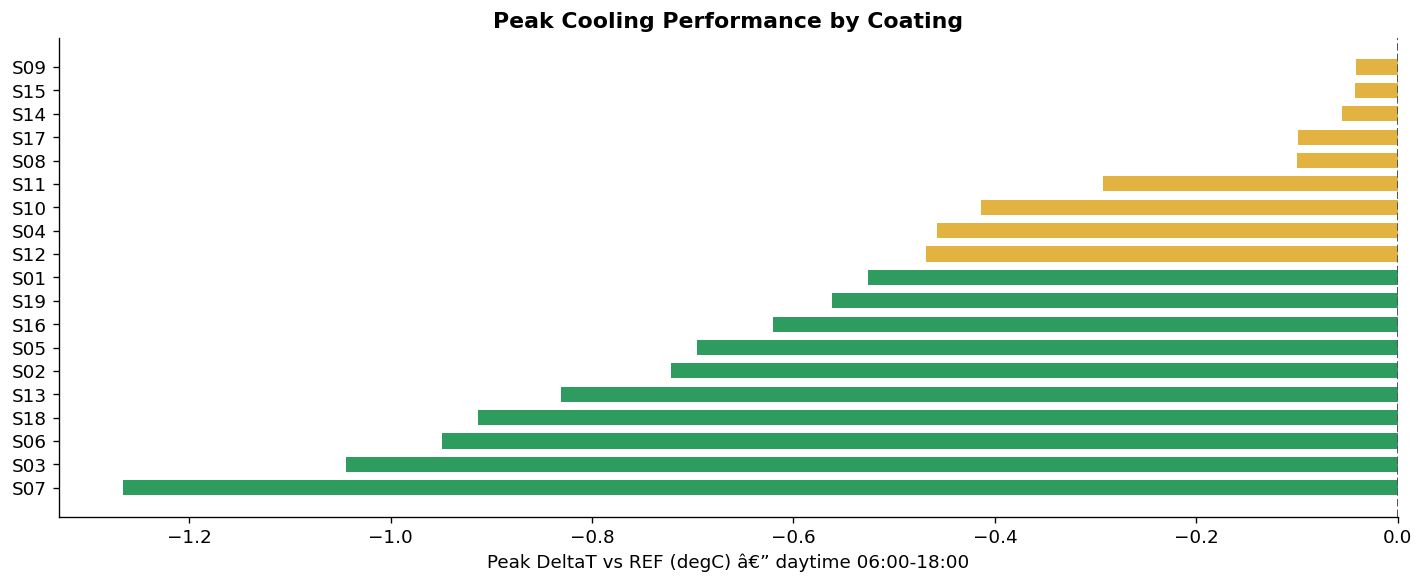

Top 5 coolest coatings:
S07   -1.266230
S03   -1.044076
S06   -0.949328
S18   -0.913647
S13   -0.830759


In [5]:
daytime  = df.between_time('06:00','18:00')
nighttime = df.between_time('19:00','05:59')

peak = daytime[sub_cols].min().sort_values()
peak.index = [c.replace('dT_','') for c in peak.index]

fig, ax = plt.subplots(figsize=(12,5))
colors = ['#2d9c5e' if v<-0.5 else '#e3b341' if v<0 else '#e05c4b' for v in peak.values]
bars = ax.barh(peak.index, peak.values, color=colors, height=0.65)
ax.axvline(0, color='#555', lw=1.2, ls='--')
for bar,val in zip(bars,peak.values):
    ax.text(val-0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}C',
            va='center', ha='right', fontsize=8, color='white', fontweight='bold')
ax.set_xlabel('Peak DeltaT vs REF (degC) â€” daytime 06:00-18:00')
ax.set_title('Peak Cooling Performance by Coating', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES/'02_peak_cooling_comparison.png', bbox_inches='tight')
plt.show()
print('Top 5 coolest coatings:')
print(peak.head(5).to_string())

## 6. Day vs Night Mean DeltaT

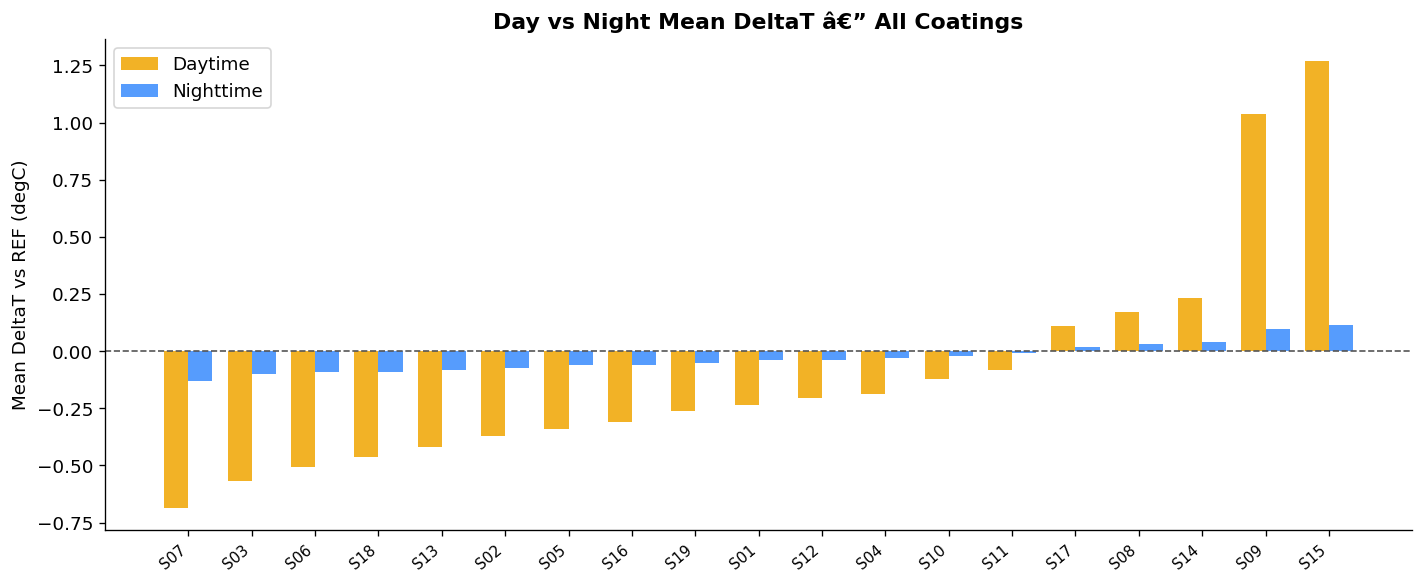

In [6]:
day_mean   = daytime[sub_cols].mean().rename(lambda c: c.replace('dT_',''))
night_mean = nighttime[sub_cols].mean().rename(lambda c: c.replace('dT_',''))
comp = pd.DataFrame({'Day (06-18h)':day_mean,'Night (19-06h)':night_mean}).sort_values('Day (06-18h)')

fig,ax = plt.subplots(figsize=(12,5))
x = np.arange(len(comp)); w=0.38
ax.bar(x-w/2, comp['Day (06-18h)'],   width=w, label='Daytime',  color='#f0a500', alpha=0.85)
ax.bar(x+w/2, comp['Night (19-06h)'], width=w, label='Nighttime',color='#388bfd', alpha=0.85)
ax.axhline(0, color='#555', lw=1, ls='--')
ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Mean DeltaT vs REF (degC)')
ax.set_title('Day vs Night Mean DeltaT â€” All Coatings', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES/'03_day_vs_night.png', bbox_inches='tight')
plt.show()

## 7. Filler Loading Effect (Low â€“ High Concentration)

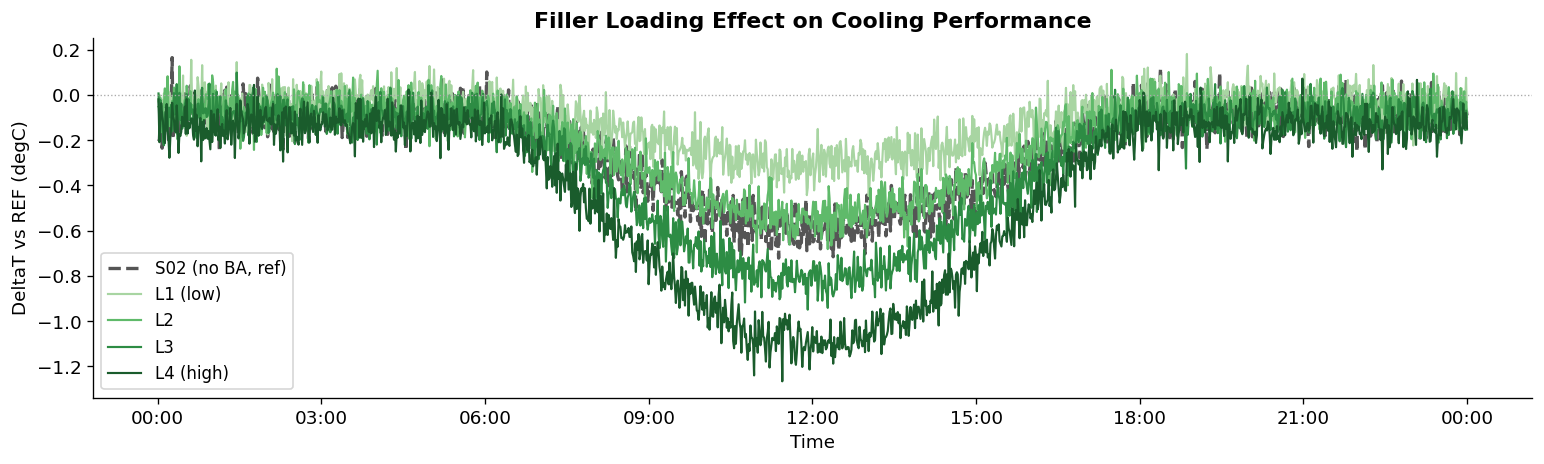

L1 (low): peak daytime DeltaT = -0.457 degC
L2: peak daytime DeltaT = -0.696 degC
L3: peak daytime DeltaT = -0.949 degC
L4 (high): peak daytime DeltaT = -1.266 degC


In [7]:
load_map = {'L1 (low)':'dT_S04','L2':'dT_S05','L3':'dT_S06','L4 (high)':'dT_S07'}
fig,ax = plt.subplots(figsize=(13,4))
ax.plot(df.index, df['dT_S02'], color='#555', lw=2, ls='--', label='S02 (no BA, ref)')
clrs = ['#a8d5a2','#5fba6a','#2d8c44','#1a5c2c']
for (label,col),c in zip(load_map.items(), clrs):
    ax.plot(df.index, df[col], lw=1.3, color=c, label=label)
ax.axhline(0, color='#aaa', lw=0.8, ls=':')
ax.set_ylabel('DeltaT vs REF (degC)')
ax.set_xlabel('Time')
ax.set_title('Filler Loading Effect on Cooling Performance', fontweight='bold')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.savefig(FIGURES/'04_ba_loading_effect.png', bbox_inches='tight')
plt.show()
for label,col in load_map.items():
    print(f'{label}: peak daytime DeltaT = {daytime[col].min():.3f} degC')

**Physical interpretation -- why more loading = better cooling (in this range).**

The S04->S07 series uses the same filler type at increasing concentration.
Peak daytime DeltaT:

| Sample | Loading | Peak DeltaT (daytime) |
|--------|---------|----------------------|
| S04    | Low (L1) | -0.46 degC |
| S05    | L2       | -0.70 degC |
| S06    | L3       | -0.95 degC |
| S07    | High (L4) | -1.27 degC |

The monotonic improvement shows that within this concentration range, adding more
filler increases the coating's infrared emittance faster than it increases solar absorptance.
The filler particles scatter incoming sunlight (increases reflectance) and provide additional
IR-emitting surface area (increases emittance). Both effects improve cooling.

This does not mean "always use more": above an optimum loading, particle aggregation
reduces optical smoothness and IR emission efficiency. The ML model in Notebook 03
learns where that optimum sits across different filler types.

## 8. Correlation Matrix (DeltaT across coatings)

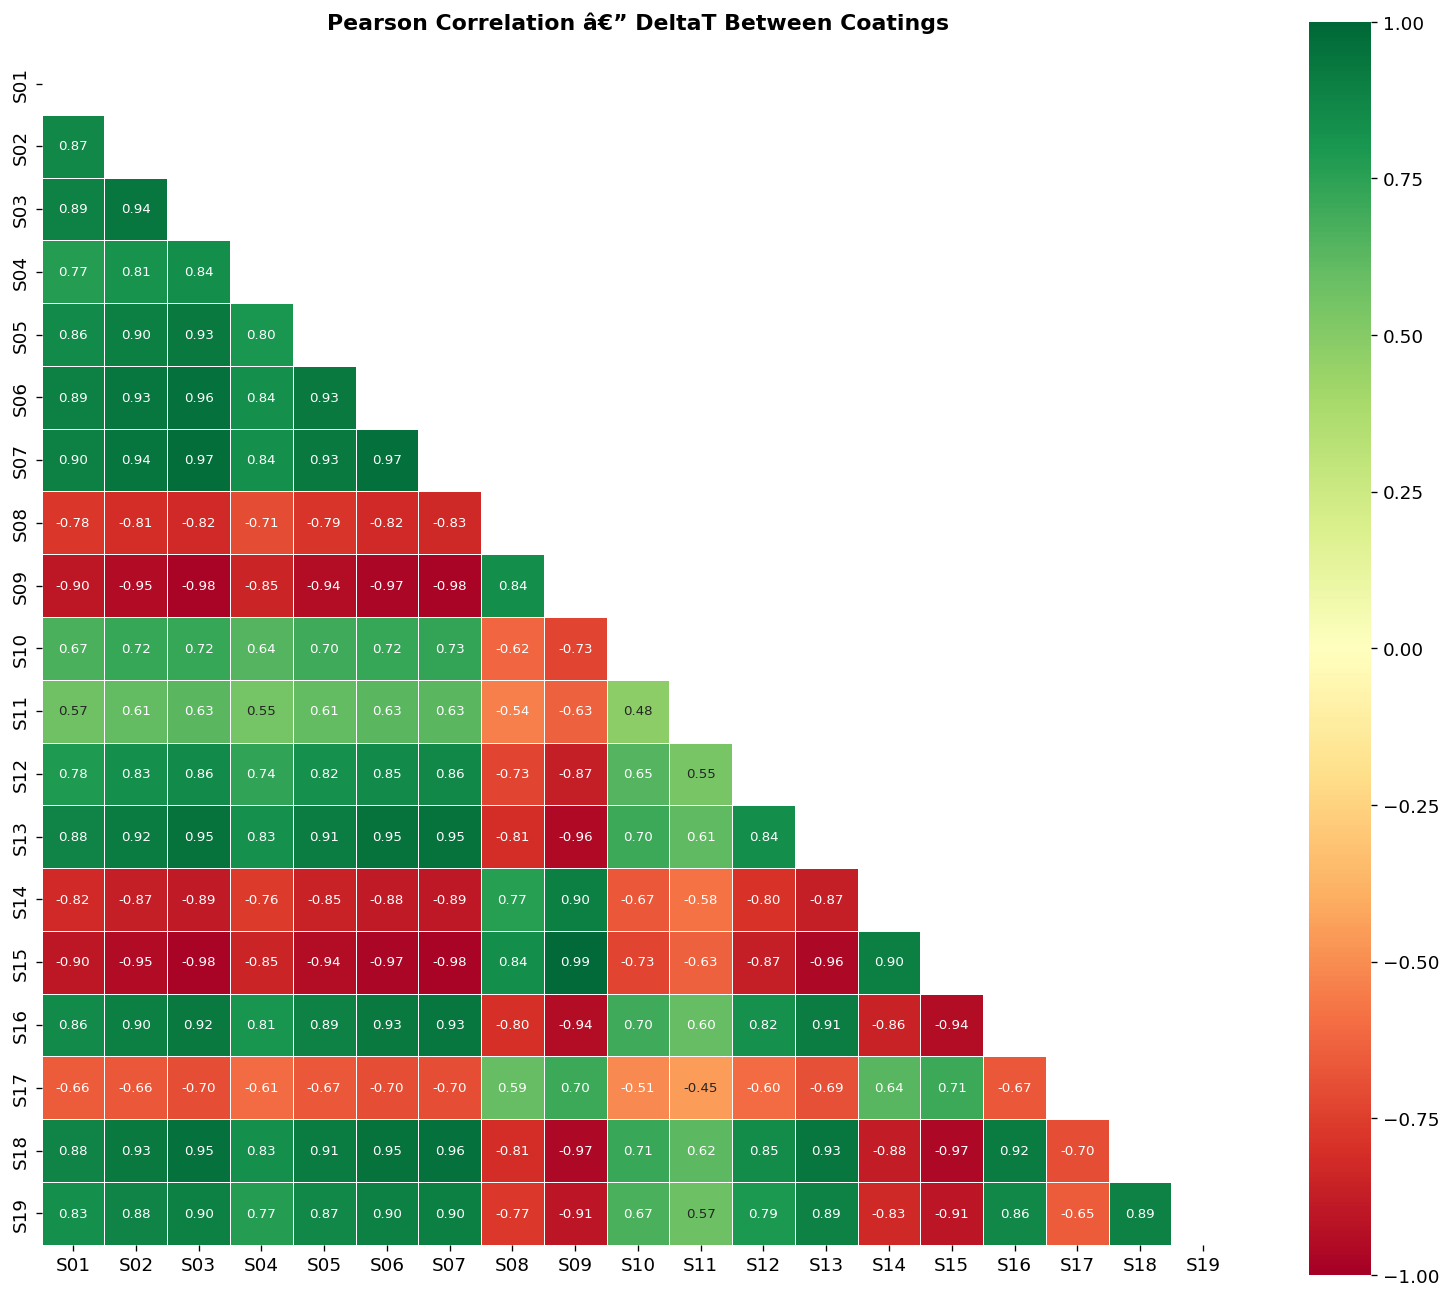

In [8]:
corr = df[sub_cols].rename(columns=lambda c: c.replace('dT_','')).corr()
fig,ax = plt.subplots(figsize=(13,11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size':8},
            linewidths=0.5, square=True)
ax.set_title('Pearson Correlation â€” DeltaT Between Coatings', fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(FIGURES/'05_correlation_matrix.png', bbox_inches='tight')
plt.show()

## 9. Summary Table

In [9]:
summary = pd.DataFrame({
    'Daytime Peak DeltaT': daytime[sub_cols].min(),
    'Daytime Mean DeltaT': daytime[sub_cols].mean(),
    'Nighttime Mean DeltaT': nighttime[sub_cols].mean(),
    'Overall Std': df[sub_cols].std(),
})
summary.index = [c.replace('dT_','') for c in summary.index]
summary.sort_values('Daytime Peak DeltaT').round(3)

,Daytime Peak DeltaT,Daytime Mean DeltaT,Nighttime Mean DeltaT,Overall Std
S07,-1.266,-0.687,-0.131,0.366
S03,-1.044,-0.569,-0.102,0.307
S06,-0.949,-0.506,-0.089,0.277
S18,-0.914,-0.464,-0.092,0.251
S13,-0.831,-0.420,-0.081,0.229
S02,-0.721,-0.372,-0.075,0.204
S05,-0.696,-0.339,-0.059,0.191
S16,-0.620,-0.311,-0.062,0.174
S19,-0.562,-0.262,-0.052,0.150
S01,-0.526,-0.234,-0.037,0.140


## 10. Key Findings & Next Steps

**Key numbers from this dataset:**
- All 19 coated samples are cooler than the bare reference at peak daytime (DeltaT < 0 for all).
- Best performer: **S07** -- peak DeltaT = **-1.27 degC** at 11:27 (near solar noon, ~30.7 degC ambient).
- Weakest performer: **S09** -- peak DeltaT = -0.04 degC (barely distinguishable from reference).
- Loading series (S04->S07): clear monotonic improvement -- -0.46 -> -0.70 -> -0.95 -> -1.27 degC --
  confirming that filler concentration is a strong, quantifiable driver of RC performance.
- Overall mean daytime DeltaT across all samples: -0.10 degC (modest average, wide spread).

**What this means for ML:**
- There is real signal in the data: a 3x performance range (-0.04 to -1.27 degC) across formulations.
- The loading series shows the data is clean and physically consistent -- a model can learn from it.
- The wide spread (not all samples are equal) means feature importance will be meaningful.

**Next step -> Notebook 02:** Extract per-sample features (peak DeltaT, mean DeltaT, time-of-peak)
and merge with formulation metadata to build the feature matrix for the Random Forest model.